# Deep Learning (CNN / RNN-LSTM / Transformer Framing)

**Author:** Ihor Melashchenko  
**Student ID:** C00290950

This notebook provides deep learning implementations aligned with module coverage.

## Implemented Scope
1. Build sequence-formatted inputs from synthetic engagement features.
2. Train a 1D CNN baseline and an LSTM baseline for dropout-risk classification.
3. Compare models with test ROC-AUC and test F1.
4. Save training/metric diagnostics for portfolio evidence.

TensorFlow available: True


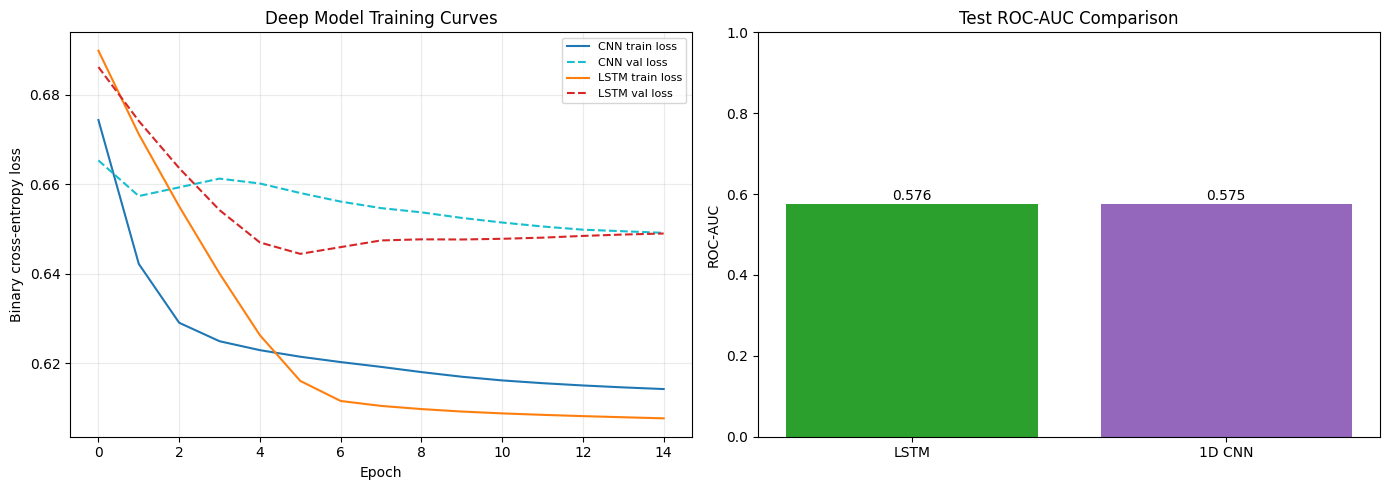

    model   test_f1  test_roc_auc
0    LSTM  0.139535      0.576250
1  1D CNN  0.000000      0.575313
Saved deep learning diagnostics figure to: /Users/ihormelashchenko/GitHub/DS-and-ML-2-CA/results/figures/03_deep_learning_comparison.png


In [1]:
# Author: Ihor Melashchenko
# Student ID: C00290950

from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_generation import generate_student_dataset

tf_available = importlib.util.find_spec('tensorflow') is not None
print('TensorFlow available:', tf_available)

feature_columns = [
    'weekly_logins',
    'avg_session_minutes',
    'timetable_views',
    'notification_click_rate',
    'attendance_rate',
    'assignment_submission_rate',
    'gpa',
]

df = generate_student_dataset()
X = df[feature_columns].values
y = df['dropout_risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Shape tabular features as short sequences (timesteps=7, channels=1)
X_train_seq = X_train_scaled.reshape((-1, 7, 1))
X_test_seq = X_test_scaled.reshape((-1, 7, 1))

if tf_available:
    import tensorflow as tf

    tf.random.set_seed(42)

    def build_cnn_model(input_shape):
        model = tf.keras.Sequential(
            [
                tf.keras.layers.Input(shape=input_shape),
                tf.keras.layers.Conv1D(filters=16, kernel_size=2, activation='relu'),
                tf.keras.layers.GlobalMaxPooling1D(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dense(1, activation='sigmoid'),
            ]
        )
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
        return model

    def build_lstm_model(input_shape):
        model = tf.keras.Sequential(
            [
                tf.keras.layers.Input(shape=input_shape),
                tf.keras.layers.LSTM(16),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dense(1, activation='sigmoid'),
            ]
        )
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
        return model

    cnn_model = build_cnn_model(input_shape=(7, 1))
    lstm_model = build_lstm_model(input_shape=(7, 1))

    cnn_history = cnn_model.fit(
        X_train_seq,
        y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=32,
        verbose=0,
    )
    lstm_history = lstm_model.fit(
        X_train_seq,
        y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=32,
        verbose=0,
    )

    cnn_prob = cnn_model.predict(X_test_seq, verbose=0).ravel()
    lstm_prob = lstm_model.predict(X_test_seq, verbose=0).ravel()

    results_df = pd.DataFrame(
        [
            {
                'model': '1D CNN',
                'test_f1': f1_score(y_test, (cnn_prob >= 0.5).astype(int)),
                'test_roc_auc': roc_auc_score(y_test, cnn_prob),
            },
            {
                'model': 'LSTM',
                'test_f1': f1_score(y_test, (lstm_prob >= 0.5).astype(int)),
                'test_roc_auc': roc_auc_score(y_test, lstm_prob),
            },
        ]
    ).sort_values(by='test_roc_auc', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(cnn_history.history['loss'], label='CNN train loss', color='tab:blue')
    axes[0].plot(cnn_history.history['val_loss'], label='CNN val loss', linestyle='--', color='tab:cyan')
    axes[0].plot(lstm_history.history['loss'], label='LSTM train loss', color='tab:orange')
    axes[0].plot(lstm_history.history['val_loss'], label='LSTM val loss', linestyle='--', color='tab:red')
    axes[0].set_title('Deep Model Training Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary cross-entropy loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].bar(results_df['model'], results_df['test_roc_auc'], color=['tab:green', 'tab:purple'])
    axes[1].set_title('Test ROC-AUC Comparison')
    axes[1].set_ylabel('ROC-AUC')
    axes[1].set_ylim(0, 1)
    for idx, value in enumerate(results_df['test_roc_auc']):
        axes[1].text(idx, value + 0.01, f'{value:.3f}', ha='center')

    fig.tight_layout()
    figure_path = PROJECT_ROOT / 'results' / 'figures' / '03_deep_learning_comparison.png'
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(results_df)
    print('Saved deep learning diagnostics figure to:', figure_path)
else:
    print('TensorFlow is not available. Deep learning models were not executed in this environment.')

## Interpretation
- Inputs are treated as short engagement sequences to support sequence-model experimentation.
- The comparison table and saved figure provide baseline evidence for CNN vs LSTM behavior on synthetic retention-risk data.
- Transformer experiments remain a next extension after this implemented baseline.